In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')
import joblib

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, roc_curve

In [2]:
# Load preprocessed data and target
X = pd.read_csv('/content/drive/MyDrive/datasets/Heart_Disease_Project/preprocessed_features.csv')
y = pd.read_csv('/content/drive/MyDrive/datasets/Heart_Disease_Project/target_binary.csv')

In [4]:
# Load selected features
selected_features = joblib.load('/content/drive/MyDrive/datasets/Heart_Disease_Project/selected_features.pkl')
X = X[selected_features]

In [6]:
# Split the dataset into training (80%) and testing (20%) sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [7]:
# Initialize models
models = {
    'Logistic Regression': LogisticRegression(max_iter=1000),
    'Decision Tree': DecisionTreeClassifier(),
    'Random Forest': RandomForestClassifier(),
    'SVM': SVC(probability=True)
}

---Logistic Regression---
Accuracy: 0.902
Precision: 0.906
Recall: 0.906
F1 Score: 0.906
AUC Score: 0.953
 
---Decision Tree---
Accuracy: 0.754
Precision: 0.774
Recall: 0.750
F1 Score: 0.762
AUC Score: 0.754
 
---Random Forest---
Accuracy: 0.836
Precision: 0.893
Recall: 0.781
F1 Score: 0.833
AUC Score: 0.933
 
---SVM---
Accuracy: 0.918
Precision: 0.966
Recall: 0.875
F1 Score: 0.918
AUC Score: 0.964
 


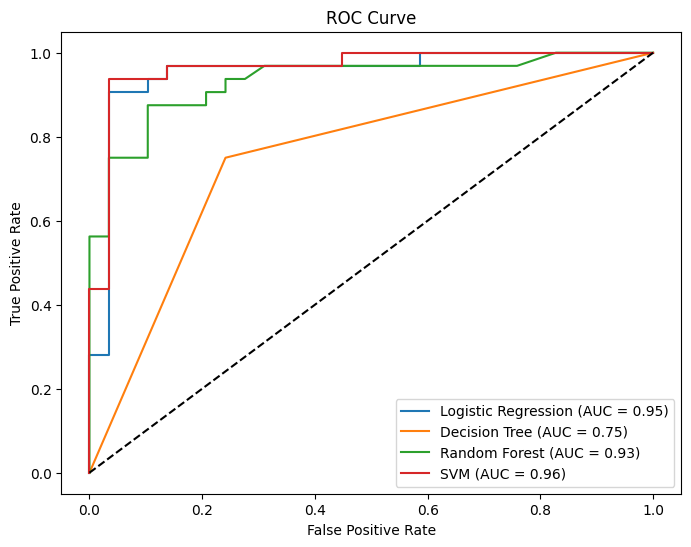

In [8]:
# Train and evaluate
plt.figure(figsize=(8,6))
for name, model in models.items():
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    y_proba = model.predict_proba(X_test)[:,1]

    print(f"---{name}---")
    print(f"Accuracy: {accuracy_score(y_test, y_pred):.3f}")
    print(f"Precision: {precision_score(y_test, y_pred):.3f}")
    print(f"Recall: {recall_score(y_test, y_pred):.3f}")
    print(f"F1 Score: {f1_score(y_test, y_pred):.3f}")
    print(f"AUC Score: {roc_auc_score(y_test, y_proba):.3f}")
    print(" ")

   # Compute and plot ROC curve
    fpr, tpr, _ = roc_curve(y_test, y_proba)
    plt.plot(fpr, tpr, label=f'{name} (AUC = {roc_auc_score(y_test, y_proba):.2f})')
plt.plot([0,1], [0,1], 'k--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve')
plt.legend()
plt.show()

In [9]:
# Save best model
best_model = models['SVM']
joblib.dump(best_model, '/content/drive/MyDrive/datasets/Heart_Disease_Project/final_model.pkl')


['/content/drive/MyDrive/datasets/Heart_Disease_Project/final_model.pkl']